In [25]:
pip install earthengine-api geemap --break-system-packages


In [26]:
# Using the OSM GEE account
## Cloud Project: osmgee
## Quota tier: Partner Tier (Until October)
 
import ee
import geemap
ee.Authenticate()
# Initialize with your project
ee.Initialize(project='osmgee')

In [27]:
# ============================================
# Load feature collections, including HUC8 boundaries
# ============================================
 
wetlands = ee.FeatureCollection('projects/osmgee/assets/OSM_Wetland')
watersheds = ee.FeatureCollection('projects/osmgee/assets/OSM_Watersheds')
huc8s = ee.FeatureCollection('projects/osmgee/assets/OSR_HUC8')
 
print('Wetland feature count:', wetlands.size().getInfo())
print('Watershed feature count:', watersheds.size().getInfo())
print('HUC8 feature count:', huc8s.size().getInfo())

Wetland feature count: 121
Watershed feature count: 121
HUC8 feature count: 110


Clipped watershed geometry materialized.


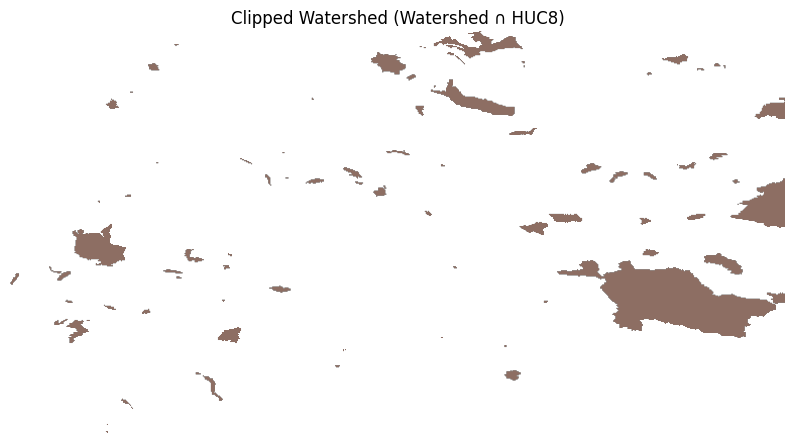

In [28]:
# ============================================
# Clip watersheds to HUC8 boundaries (intersection)
# ============================================
 
watershed_geom = watersheds.geometry()
wetland_geom = wetlands.geometry()
huc8_geom = huc8s.geometry()
 
clippedWatershed_geom = watershed_geom.intersection(huc8_geom, maxError=1)
 
# Materialize it now (compute once), same lesson as the earlier
# watershed_minus_wetland fix — avoids recomputing this expensive
# vector operation every time it's referenced downstream
clippedWatershed_geom = ee.Geometry(clippedWatershed_geom.getInfo())
 
print('Clipped watershed geometry materialized.')
 
study_area = watershed_geom.union(wetland_geom).dissolve()
 
# ============================================
# Visualize clippedWatershed_geom only
# ============================================
 
clipped_feature = ee.FeatureCollection([ee.Feature(clippedWatershed_geom)])
 
clipped_image = ee.Image().byte().paint(
    featureCollection=clipped_feature,
    color=1
)
 
thumb_url = clipped_image.getThumbURL({
    'min': 0,
    'max': 1,
    'palette': ['white', '#8D6E63'],
    'dimensions': 768,
    'region': clippedWatershed_geom,
})
 
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt
 
response = requests.get(thumb_url)
img = Image.open(BytesIO(response.content))
 
plt.figure(figsize=(10, 10))
plt.imshow(img)
plt.axis('off')
plt.title('Clipped Watershed (Watershed \u2229 HUC8)')
plt.show()
 

In [12]:
# ============================================
# Study period and growing season window
# ============================================
start_year = 1985
end_year = 2025
 
start_month = 6   # June
end_month = 8     # August

In [13]:
# ============================================
# STEP 2: Build harmonized Landsat collection (1985-2025)
# ============================================
 
def mask_l457(image):
    """Cloud/shadow/snow mask for Landsat 4/5/7 Collection 2 SR."""
    qa = image.select('QA_PIXEL')
    # Bits: 1=Dilated Cloud, 3=Cloud, 4=Cloud Shadow, 5=Snow
    cloud_shadow_bit = 1 << 4
    clouds_bit = 1 << 3
    snow_bit = 1 << 5
    mask = (qa.bitwiseAnd(cloud_shadow_bit).eq(0)
            .And(qa.bitwiseAnd(clouds_bit).eq(0))
            .And(qa.bitwiseAnd(snow_bit).eq(0)))
    return image.updateMask(mask)
 
 
def mask_l89(image):
    """Cloud/shadow/snow mask for Landsat 8/9 Collection 2 SR."""
    qa = image.select('QA_PIXEL')
    cloud_shadow_bit = 1 << 4
    clouds_bit = 1 << 3
    snow_bit = 1 << 5
    mask = (qa.bitwiseAnd(cloud_shadow_bit).eq(0)
            .And(qa.bitwiseAnd(clouds_bit).eq(0))
            .And(qa.bitwiseAnd(snow_bit).eq(0)))
    return image.updateMask(mask)
 
 
def rename_l457(image):
    """Harmonize Landsat 4/5/7 band names to common names."""
    return image.select(
        ['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B7'],
        ['Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2']
    ).copyProperties(image, ['system:time_start', 'SPACECRAFT_ID'])
 
 
def rename_l89(image):
    """Harmonize Landsat 8/9 band names to common names."""
    return image.select(
        ['SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B6', 'SR_B7'],
        ['Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2']
    ).copyProperties(image, ['system:time_start', 'SPACECRAFT_ID'])
 
 
def apply_scale_factors(image):
    """Apply Collection 2 SR scale factors to get true reflectance."""
    optical_bands = image.select(
        ['Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2']
    ).multiply(0.0000275).add(-0.2)
    return image.addBands(optical_bands, None, True)
 
 
# Load each sensor's Collection 2 Level-2 SR collection, filtered to study area + date range
l5 = (ee.ImageCollection('LANDSAT/LT05/C02/T1_L2')
      .filterBounds(study_area)
      .filterDate('1985-01-01', '2013-01-01')
      .map(mask_l457)
      .map(rename_l457))
 
l7 = (ee.ImageCollection('LANDSAT/LE07/C02/T1_L2')
      .filterBounds(study_area)
      .filterDate('1999-01-01', '2022-01-01')  # SLC-off after 2003, but keep for gap-fill overlap
      .map(mask_l457)
      .map(rename_l457))
 
l8 = (ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
      .filterBounds(study_area)
      .filterDate('2013-01-01', '2025-12-31')
      .map(mask_l89)
      .map(rename_l89))
 
l9 = (ee.ImageCollection('LANDSAT/LC09/C02/T1_L2')
      .filterBounds(study_area)
      .filterDate('2021-10-01', '2025-12-31')
      .map(mask_l89)
      .map(rename_l89))
 
# Merge all sensors into one collection, apply scale factors, keep SPACECRAFT_ID
landsat_all = (l5.merge(l7).merge(l8).merge(l9)
               .map(apply_scale_factors))
 
print('Total merged Landsat scenes:', landsat_all.size().getInfo())
 
# Sanity check — inspect one image's bands and a property
first_img = landsat_all.first()
print('Band names:', first_img.bandNames().getInfo())
print('SPACECRAFT_ID:', first_img.get('SPACECRAFT_ID').getInfo())

Total merged Landsat scenes: 6724
Band names: ['Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2']
SPACECRAFT_ID: LANDSAT_5


In [41]:
# ============================================
# Filter to growing season + sort by cloud cover
# ============================================
 
def add_cloud_cover_property(image):
    """Ensure CLOUD_COVER is accessible as a numeric property for sorting/filtering."""
    return image.set('CLOUD_COVER', ee.Number(image.get('CLOUD_COVER')))
 
 
# Filter the merged collection to the growing season window (across all years)
landsat_growing_season = (landsat_all
    .filter(ee.Filter.calendarRange(start_month, end_month, 'month'))
    .filter(ee.Filter.calendarRange(start_year, end_year, 'year'))
    .map(add_cloud_cover_property))
 
MAX_CLOUD_COVER = 50  # percent
 
landsat_filtered = landsat_growing_season.filter(
    ee.Filter.lte('CLOUD_COVER', MAX_CLOUD_COVER)
)
 
landsat_sorted = landsat_filtered.sort('CLOUD_COVER')
 
print('Scenes before cloud filter:', landsat_growing_season.size().getInfo())
print('Scenes after cloud filter (<= {}%):'.format(MAX_CLOUD_COVER),
      landsat_filtered.size().getInfo())
 
cloud_values = landsat_sorted.limit(5).aggregate_array('CLOUD_COVER').getInfo()
print('Cloud cover of 5 least-cloudy scenes:', cloud_values)
 
 
def clip_to_study_area(image):
    """Clip image to study area to reduce computation to only relevant pixels."""
    return image.clip(clippedWatershed_geom)
 
 
# Apply clipping to the CLOUD-FILTERED collection (landsat_filtered), not
# the raw landsat_all — otherwise the MAX_CLOUD_COVER scene-level filter
# above is computed but never actually applied downstream.
landsat_all_clipped = landsat_filtered.map(clip_to_study_area)

Scenes before cloud filter: 2467
Scenes after cloud filter (<= 50%): 1402
Cloud cover of 5 least-cloudy scenes: [0, 0, 0, 0, 0]


In [42]:
# ============================================
# STEP 3: Annual medoid composites, REFLECTANCE BANDS ONLY.
# Medoid distance and selection both operate purely on the 6 reflectance
# bands — no indices computed yet. Whichever real scene is closest to
# the season's median reflectance profile is kept, per pixel.
# ============================================
 
REFLECTANCE_BANDS = ['Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2']
 
# landsat_all_clipped is already filtered to the growing season window
# (via landsat_growing_season, upstream) and to MAX_CLOUD_COVER — no
# need to re-filter by month here.
landsat_growing_season_bands = landsat_all_clipped
 
print('Scenes in June-Aug window (all years):', landsat_growing_season_bands.size().getInfo())
 
 
def medoid_composite_reflectance(collection):
    median = collection.select(REFLECTANCE_BANDS).median()
 
    def add_distance(image):
        diff = image.select(REFLECTANCE_BANDS).subtract(median).pow(2)
        distance = diff.reduce(ee.Reducer.sum()).sqrt().rename('distance')
        return image.addBands(distance)
 
    with_distance = collection.map(add_distance)
 
    def negate_distance(image):
        return image.addBands(image.select('distance').multiply(-1).rename('neg_distance'))
 
    with_neg_distance = with_distance.map(negate_distance)
 
    medoid = with_neg_distance.qualityMosaic('neg_distance')
 
    return medoid.select(REFLECTANCE_BANDS)
 
 
def make_annual_composite_reflectance(year):
    """Build one annual reflectance-only medoid composite for a given year."""
    year = ee.Number(year)
    start = ee.Date.fromYMD(year, start_month, 1)
    end = ee.Date.fromYMD(year, end_month, 31)
 
    yearly_scenes = landsat_growing_season_bands.filterDate(start, end.advance(1, 'day'))
 
    composite = (medoid_composite_reflectance(yearly_scenes)
        .set('year', year)
        .set('system:time_start', start.millis())
        .set('scene_count', yearly_scenes.size()))
 
    return composite

Scenes in June-Aug window (all years): 1402


In [43]:
# ============================================
# STEP 4: Compute NDVI, EVI, NDWI FROM the annual medoid composite's own
# reflectance bands — indices are derived once, at the composite level,
# from the exact pixel values that were already medoid-selected.
# NDVI stays first — LandTrendr uses the first band to drive segmentation;
# every other band gets fitted to that same segment structure via FTV.
# ============================================
 
def add_all_indices(image):
    """Compute NDVI, EVI, and NDWI from a composite's reflectance bands."""
    ndvi = image.normalizedDifference(['NIR', 'Red']).rename('NDVI')
 
    evi = image.expression(
        '2.5 * ((NIR - RED) / (NIR + 6 * RED - 7.5 * BLUE + 1))',
        {
            'NIR': image.select('NIR'),
            'RED': image.select('Red'),
            'BLUE': image.select('Blue')
        }
    ).rename('EVI')
 
    ndwi = image.normalizedDifference(['Green', 'NIR']).rename('NDWI')
 
    return image.addBands([ndvi, evi, ndwi])
 
 
ALL_BANDS = ['NDVI', 'Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2', 'EVI', 'NDWI']
 
 
def make_annual_composite_multiband(year):
    """Build one annual composite: medoid on reflectance, then indices added."""
    composite = make_annual_composite_reflectance(year)
    composite_with_indices = add_all_indices(composite)
    return (composite_with_indices
        .select(ALL_BANDS)
        .copyProperties(composite, ['year', 'system:time_start', 'scene_count']))

In [44]:
# ============================================
# STEP 5: Build the 41-year collection directly in memory — no
# intermediate export/reload. Each year's composite is only actually
# computed when something downstream forces evaluation (i.e. STEP 6).
# ============================================
 
years_range = list(range(start_year, end_year + 1))
annual_composites_list = [make_annual_composite_multiband(y) for y in years_range]
 
multiband_collection = ee.ImageCollection.fromImages(annual_composites_list)
 

In [45]:
# ============================================
# STEP 6: Run LandTrendr directly on the in-memory multi-band collection.
# NDVI (first band) drives segmentation; every other band is fitted to
# that same segment structure automatically via LandTrendr's FTV
# mechanism — output includes NDVI's own array PLUS separately named
# "_fit" bands for Blue, Green, Red, NIR, SWIR1, SWIR2, EVI, NDWI.
#
# NOTE: skipping the intermediate export means this single step now
# carries the full cost of building 41 years of medoid composites AND
# running LandTrendr, all in one lazy chain. Given how often earlier,
# lighter operations hit GEE's interactive memory/timeout limits today,
# this step is at real risk of the same failure — if it times out, the
# fix is to reintroduce an export-and-reload step for the composites
# (STEP 5) before attempting LandTrendr.
# ============================================
 
ASSET_PROJECT = 'projects/annual-ccdc-new/assets'
 
LANDTRENDR_PARAMS = {
    'maxSegments': 6,
    'spikeThreshold': 0.9,
    'vertexCountOvershoot': 3,
    'preventOneYearRecovery': True,
    'recoveryThreshold': 0.25,
    'pvalThreshold': 0.05,
    'bestModelProportion': 0.75,
    'minObservationsNeeded': 6,
}
 
lt_collection_mb = multiband_collection.sort('year')
 
lt_params_mb = dict(LANDTRENDR_PARAMS)
lt_params_mb['timeSeries'] = lt_collection_mb.select(ALL_BANDS)
 
lt_result_mb = ee.Algorithms.TemporalSegmentation.LandTrendr(**lt_params_mb)
 

# Expect: ['LandTrendr', 'Blue_fit', 'Green_fit', 'Red_fit', 'NIR_fit',
#          'SWIR1_fit', 'SWIR2_fit', 'EVI_fit', 'NDWI_fit', 'rmse']

In [46]:
# ============================================
# STEP 7: Extract ONE specific year, all fit bands, and export.
# ============================================

TARGET_YEAR = 2025  # change this to export a different year

fit_band_names = [b + '_fit' for b in ALL_BANDS if b != 'NDVI']


def extract_fit_year(fit_band_name, year):
    """Per-pixel-safe extraction of one year from one FTV band's array."""
    array = lt_result_mb.select(fit_band_name)
    years_row_ = array.arraySlice(0, 0, 1)
    fitted_row_ = array.arraySlice(0, 1, 2)

    year_num = ee.Number(year)
    year_match_mask = years_row_.eq(year_num)
    matched_fitted = fitted_row_.arrayMask(year_match_mask)

    return (matched_fitted
        .arrayReduce(ee.Reducer.mean(), [1])
        .arrayProject([0])
        .arrayFlatten([[fit_band_name]]))


fit_bands_one_year = [extract_fit_year(b, TARGET_YEAR) for b in fit_band_names]
fit_image_one_year = ee.Image.cat(fit_bands_one_year)

# NOTE: skipped the .bandNames().getInfo() print here — it forces GEE to
# interactively recompute the entire chain (41 years of composites +
# LandTrendr + extraction), which is why this hit the memory limit.
# The export below runs server-side and can handle this scale of
# computation; we'll confirm the bands exist once the export completes.

fit_export_task_mb = ee.batch.Export.image.toAsset(
    image=fit_image_one_year,
    description=f'LandTrendr_multiband_fit_{TARGET_YEAR}',
    assetId=f'{ASSET_PROJECT}/LandTrendr_multiband_fit_{TARGET_YEAR}',
    region=watershed_geom,
    scale=30,
    maxPixels=1e10
)

fit_export_task_mb.start()
print('Multi-band LandTrendr fit export started. Task ID:', fit_export_task_mb.id)
print('Check status with: fit_export_task_mb.status()["state"]')

Multi-band LandTrendr fit export started. Task ID: 2W2C5DB2H634UHEJQD3NSEKE
Check status with: fit_export_task_mb.status()["state"]
